In [ ]:
import sys
sys.path.append("Normalized-Attention-Guidance")
import torch
import torch
from nag import NAGFluxPipeline
from nag import NAGFluxTransformer2DModel

transformer = NAGFluxTransformer2DModel.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    subfolder="transformer",
    torch_dtype=torch.bfloat16,
)
pipe = NAGFluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    transformer=transformer,
    torch_dtype=torch.bfloat16,
)
pipe = pipe.to("cuda:2")

/home/wg25r/miniconda/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.50it/s]


In [4]:
prompt = "Portrait of AI researcher."
nag_negative_prompt = "Glasses."

image = pipe(
    prompt,
    nag_negative_prompt=nag_negative_prompt,
    guidance_scale=0.0,
    nag_scale=3.0,
    num_inference_steps=4,
    max_sequence_length=256,
).images[0]

100%|██████████| 4/4 [00:06<00:00,  1.55s/it]


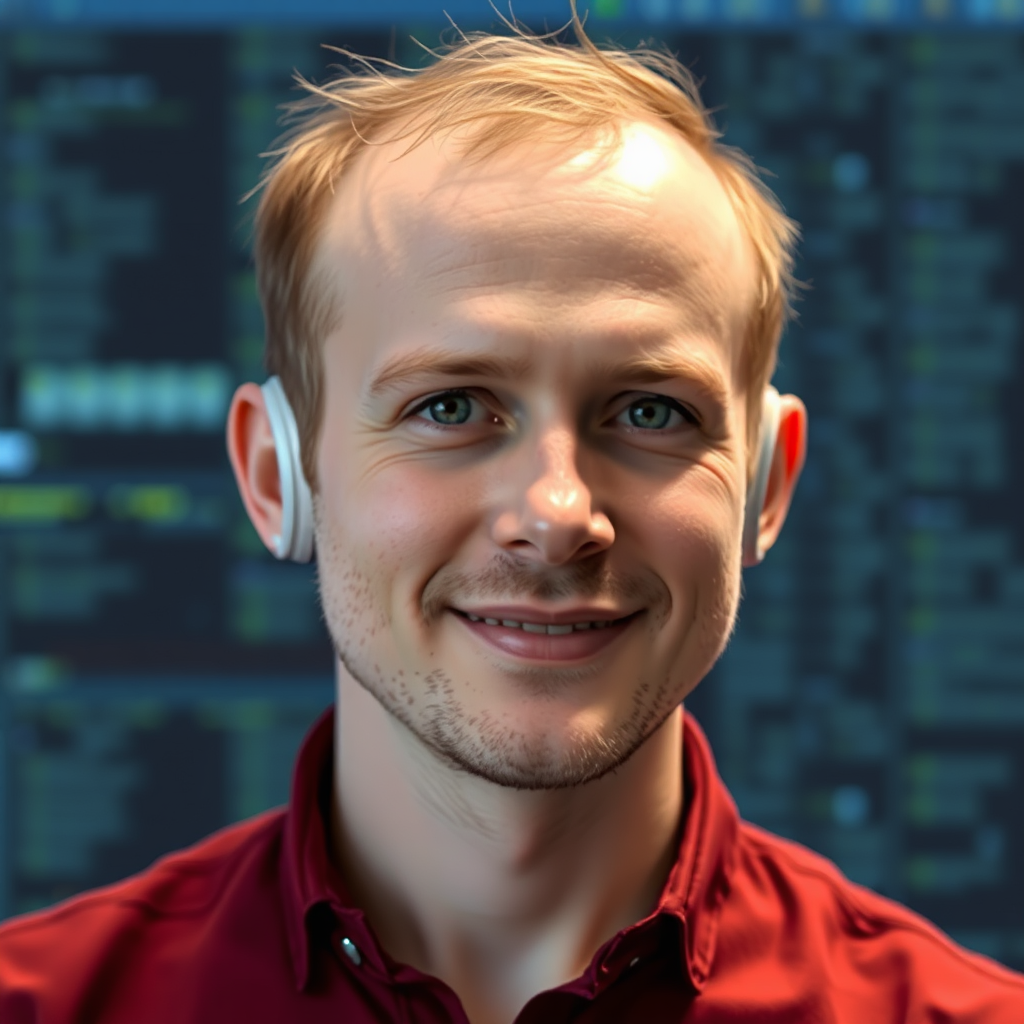

In [3]:
image